#### Setup & Imports

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

In [2]:
sys.path.append('..')  # so src/ is importable from notebooks/
from src.utils import get_raw_dir
from src.preprocessing import resolve_patient_labels, CLASS_MAP

#### 1. Download Dataset (kagglehub)

In [3]:
RAW_DIR = get_raw_dir()
print(RAW_DIR)
os.listdir(RAW_DIR)

C:\Users\ariba\.cache\kagglehub\competitions\rsna-pneumonia-detection-challenge


['GCP Credits Request Link - RSNA.txt',
 'stage_2_detailed_class_info.csv',
 'stage_2_sample_submission.csv',
 'stage_2_test_images',
 'stage_2_train_images',
 'stage_2_train_labels.csv']

#### 2. Load stage_2_train_labels.csv

In [4]:
labels_df = pd.read_csv(RAW_DIR / "stage_2_train_labels.csv")

In [5]:
labels_df.shape

(30227, 6)

In [6]:
labels_df.columns.tolist()

['patientId', 'x', 'y', 'width', 'height', 'Target']

In [7]:
labels_df['patientId'].nunique()

26684

In [8]:
labels_df.isnull().sum() 

patientId        0
x            20672
y            20672
width        20672
height       20672
Target           0
dtype: int64

In [9]:
labels_df[labels_df['Target']==0].head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0


In [10]:
labels_df['Target'].value_counts() 

Target
0    20672
1     9555
Name: count, dtype: int64

#### 3. Load stage_2_detailed_class_info.csv — 3-Class Breakdown

In [11]:
class_info_df = pd.read_csv(RAW_DIR / "stage_2_detailed_class_info.csv")

In [12]:
class_info_df.shape

(30227, 2)

In [13]:
class_info_df.columns.tolist()

['patientId', 'class']

In [14]:
class_info_df['class'].value_counts()

class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

##### Merge label sources

Using pd.concat instead of pd.merge on patientId — a merge caused row duplication (30227 → 37629) since both CSVs share duplicate patientIds for multi-box patients. Concat is safe here because both CSVs are confirmed row-aligned.

In [15]:
merged_df = pd.concat([labels_df, class_info_df['class']], axis=1)

In [16]:
merged_df.shape

(30227, 7)

In [17]:
pd.crosstab(merged_df['class'], merged_df['Target'])

Target,0,1
class,,
Lung Opacity,0,9555
No Lung Opacity / Not Normal,11821,0
Normal,8851,0


##### Decision: 3-Class Classification

Normal=0, No Lung Opacity/Not Normal=1, Lung Opacity=2 — chosen over binary to preserve the clinical distinction RSNA provides.

In [18]:
merged_df['label'] = merged_df['class'].map(CLASS_MAP)

In [19]:
merged_df['label'].value_counts()

label
1    11821
2     9555
0     8851
Name: count, dtype: int64

#### 4. DICOM Exploration (pydicom)

In [20]:
sample_ids = merged_df.groupby('label')['patientId'].first().tolist()

PatientId: 003d8fa0-6bf1-40ed-b54c-ac657f8495c5
  Age: 28, Sex: M, View: PA, Modality: CR
  Shape: (1024, 1024), Dtype: uint8, Min: 0, Max: 253
--------------------------------------------------
PatientId: 0004cfab-14fd-4e49-80ba-63a80b6bddd6
  Age: 51, Sex: F, View: PA, Modality: CR
  Shape: (1024, 1024), Dtype: uint8, Min: 0, Max: 245
--------------------------------------------------
PatientId: 00436515-870c-4b36-a041-de91049b9ab4
  Age: 32, Sex: F, View: AP, Modality: CR
  Shape: (1024, 1024), Dtype: uint8, Min: 0, Max: 255
--------------------------------------------------


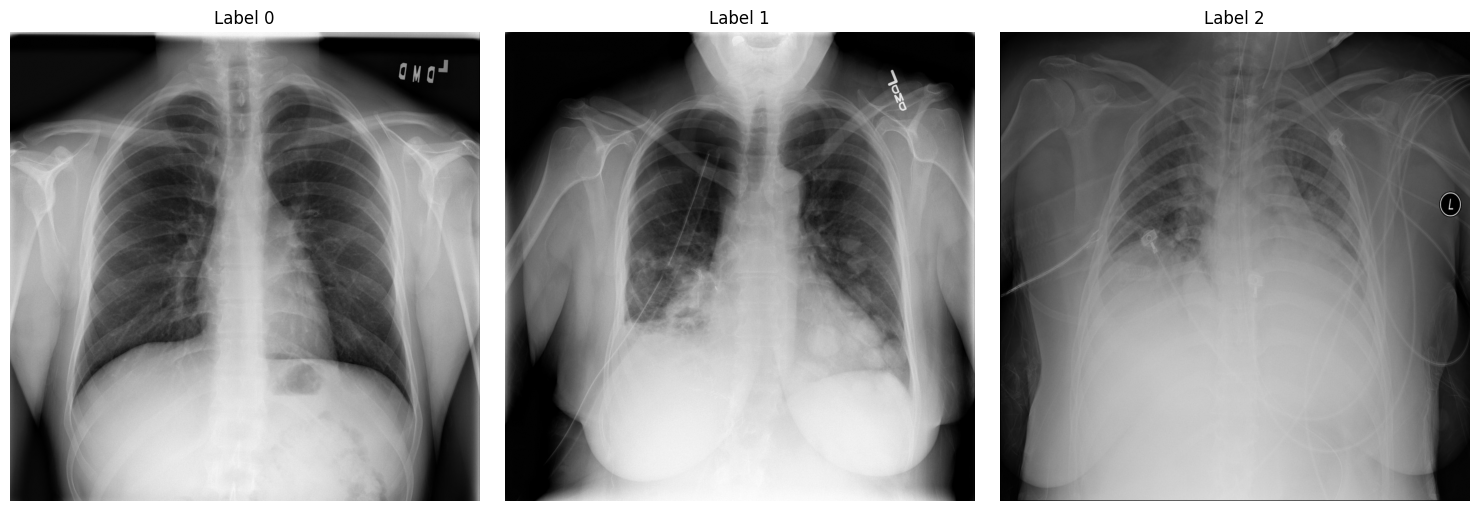

In [21]:
fig, axes = plt.subplots(1, len(sample_ids), figsize=(15, 5))

for i, pid in enumerate(sample_ids):
    dcm_path = RAW_DIR / "stage_2_train_images" / f"{pid}.dcm"
    ds = pydicom.dcmread(dcm_path)
    img = ds.pixel_array

    print(f"PatientId: {pid}")
    print(f"  Age: {ds.PatientAge}, Sex: {ds.PatientSex}, View: {ds.ViewPosition}, Modality: {ds.Modality}")
    print(f"  Shape: {img.shape}, Dtype: {img.dtype}, Min: {img.min()}, Max: {img.max()}")
    print("-" * 50)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label {merged_df.loc[merged_df['patientId']==pid, 'label'].values[0]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### 5. Resolve Multi-Box Patients → One Row per patientId

In [22]:
patient_labels = resolve_patient_labels(merged_df)

In [23]:
patient_labels.shape  


(26684, 4)

In [24]:
patient_labels['label'].value_counts() 

label
1    11821
0     8851
2     6012
Name: count, dtype: int64

#### 6. Confirm No Leakage — One Image per Patient

In [25]:
image_files = os.listdir(RAW_DIR / "stage_2_train_images")

In [26]:
len(image_files)

26684

In [27]:
image_ids = set(f.replace('.dcm', '') for f in image_files)

In [28]:
label_ids = set(patient_labels['patientId'])

In [29]:
len(image_ids), len(label_ids)

(26684, 26684)

In [30]:
image_ids == label_ids  # should be True

True

#### 7. Class Balance (Patient-Level)

In [31]:
class_counts = patient_labels['label'].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

In [32]:
print(class_counts)

label
0     8851
1    11821
2     6012
Name: count, dtype: int64


In [33]:
print(class_pct)

label
0    33.17
1    44.30
2    22.53
Name: count, dtype: float64


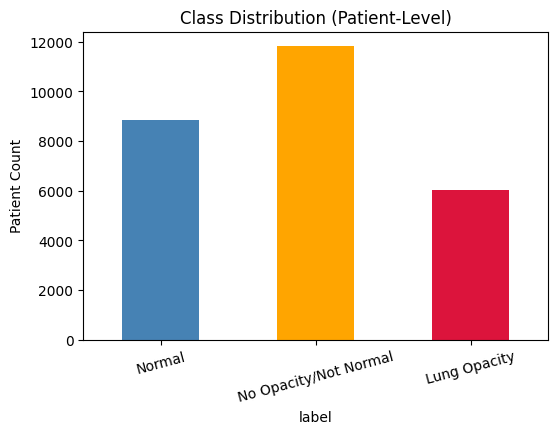

Saving to ../outputs/figures/class_distribution.png


In [34]:
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color=['steelblue', 'orange', 'crimson'])
plt.xticks([0,1,2], ['Normal', 'No Opacity/Not Normal', 'Lung Opacity'], rotation=15)
plt.ylabel('Patient Count')
plt.title('Class Distribution (Patient-Level)')
plt.savefig('../outputs/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saving to ../outputs/figures/class_distribution.png")

In [35]:
total = class_counts.sum()
class_weights = total / (len(class_counts) * class_counts)
print(class_weights)

label
0    1.004934
1    0.752446
2    1.479485
Name: count, dtype: float64


#### 8. Stratified Train/Val/Test Split (70/15/15, by patientId)

In [36]:
train_val_df, test_df = train_test_split(
       patient_labels,
       test_size=0.15,
       stratify=patient_labels['label'],
       random_state=42
   )

In [37]:
train_df, val_df = train_test_split(
       train_val_df,
       test_size=0.1765,  # ~15% of original, since it's 15% of the remaining 85%
       stratify=train_val_df['label'],
       random_state=42
   )

In [38]:
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df['label'].value_counts(normalize=True).round(3))
print(val_df['label'].value_counts(normalize=True).round(3))
print(test_df['label'].value_counts(normalize=True).round(3))

(18677, 4) (4004, 4) (4003, 4)
label
1    0.443
0    0.332
2    0.225
Name: proportion, dtype: float64
label
1    0.443
0    0.332
2    0.225
Name: proportion, dtype: float64
label
1    0.443
0    0.332
2    0.225
Name: proportion, dtype: float64


In [39]:
print(set(train_df['patientId']) & set(val_df['patientId']))
print(set(train_df['patientId']) & set(test_df['patientId']))
print(set(val_df['patientId']) & set(test_df['patientId']))

set()
set()
set()


#### 9. Save Splits & Processed Labels

In [40]:
train_df.to_csv('../data/splits/train.csv', index=False)
val_df.to_csv('../data/splits/val.csv', index=False)
test_df.to_csv('../data/splits/test.csv', index=False)

In [41]:
patient_labels.to_csv('../data/processed/labels.csv', index=False)